In [1]:
import pandas as pd
from pymongo import MongoClient
import src.config as cloud_config
import local.config as local_config
import matplotlib.pyplot as plt

# -------------------------
# CONNECT TO ATLAS
# -------------------------
atlas_client = MongoClient(cloud_config.MONGO_URI)
atlas_db = atlas_client["fit3182_awas"]

atlas_latency = pd.DataFrame(list(atlas_db.stream_latency.find()))
atlas_metrics = pd.DataFrame(list(atlas_db.stream_metrics.find()))

atlas_latency["source"] = "atlas"
atlas_metrics["source"] = "atlas"

# -------------------------
# CONNECT TO LOCAL DOCKER
# -------------------------
local_client = MongoClient(local_config.IP_ADDRESS, 27017)
local_db = local_client["fit3182_awas"]

local_latency = pd.DataFrame(list(local_db.stream_latency.find()))
local_metrics = pd.DataFrame(list(local_db.stream_metrics.find()))

local_latency["source"] = "local"
local_metrics["source"] = "local"

In [2]:
latency_df = pd.concat([atlas_latency, local_latency], ignore_index=True)
metrics_df = pd.concat([atlas_metrics, local_metrics], ignore_index=True)

<Figure size 640x480 with 0 Axes>

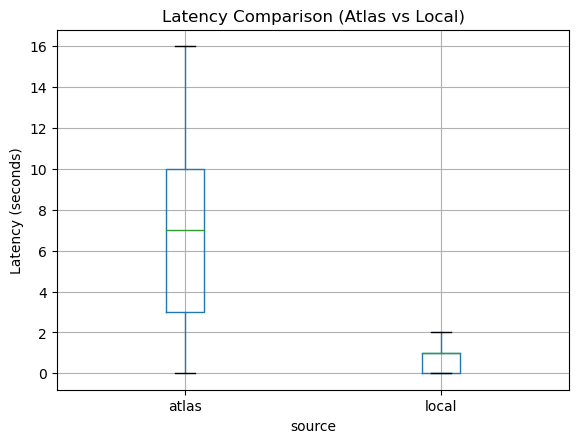

In [3]:
plt.figure()
latency_df.boxplot(column="latency_seconds", by="source")
plt.title("Latency Comparison (Atlas vs Local)")
plt.suptitle("")
plt.ylabel("Latency (seconds)")
plt.show()

## Throughput Over Time (Input Rows/sec)

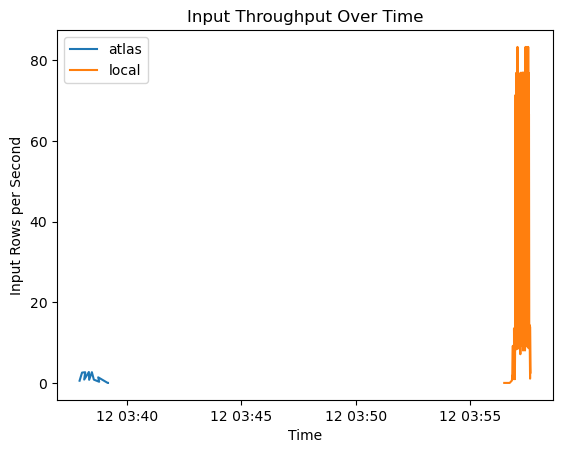

In [4]:
metrics_df["timestamp"] = pd.to_datetime(metrics_df["timestamp"])

plt.figure()

for source in metrics_df["source"].unique():
    subset = metrics_df[metrics_df["source"] == source]
    plt.plot(subset["timestamp"], subset["input_rows_per_second"], label=source)

plt.title("Input Throughput Over Time")
plt.xlabel("Time")
plt.ylabel("Input Rows per Second")
plt.legend()
plt.show()

## 5. Processing Throughput Comparison

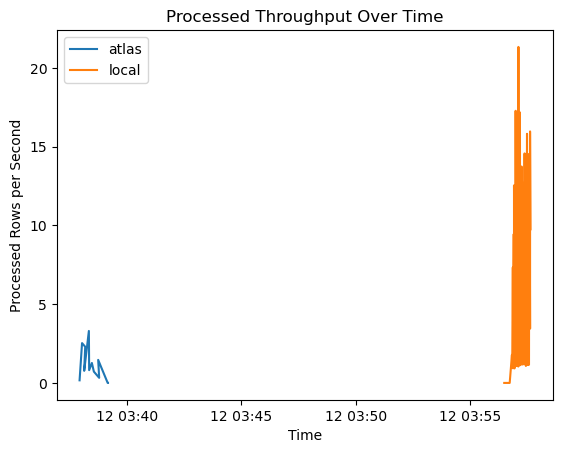

In [5]:
plt.figure()

for source in metrics_df["source"].unique():
    subset = metrics_df[metrics_df["source"] == source]
    plt.plot(subset["timestamp"], subset["processed_rows_per_second"], label=source)

plt.title("Processed Throughput Over Time")
plt.xlabel("Time")
plt.ylabel("Processed Rows per Second")
plt.legend()
plt.show()

## Average Throughput Summary (Bar Chart)

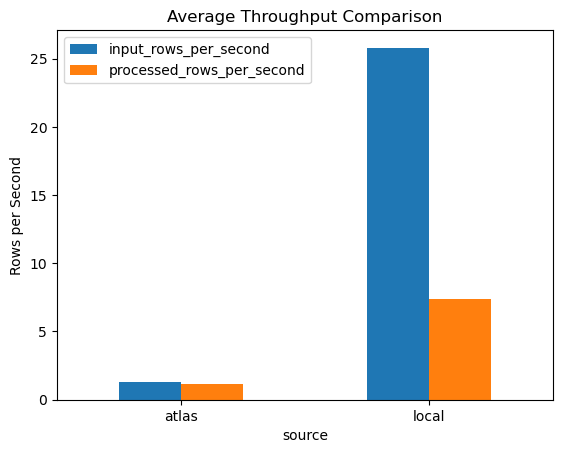

In [6]:
summary = metrics_df.groupby("source")[[
    "input_rows_per_second",
    "processed_rows_per_second"
]].mean()

summary.plot(kind="bar")
plt.title("Average Throughput Comparison")
plt.ylabel("Rows per Second")
plt.xticks(rotation=0)
plt.show()